# Spectra-Learning: Architecture & Data Visualization

Comprehensive diagrams of the **PeakSetSIGReg** model architecture, data pipeline, two-view augmentation strategy, and training flow.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

matplotlib.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.size": 10,
})

# ── Colour palette ──────────────────────────────────────────────────────────
C = {
    "data":      "#4ECDC4",  # teal
    "fourier":   "#45B7D1",  # sky blue
    "embed":     "#96CEB4",  # sage
    "encoder":   "#FFEAA7",  # warm yellow
    "attn":      "#DDA0DD",  # plum
    "ffn":       "#F0E68C",  # khaki
    "pool":      "#FF6B6B",  # coral
    "proj":      "#C39BD3",  # lavender
    "loss":      "#E74C3C",  # red
    "aug_v1":    "#FF8C42",  # orange (masked view)
    "aug_v2":    "#5DADE2",  # blue (clean view)
    "pipeline":  "#82E0AA",  # mint
    "probe":     "#F1948A",  # salmon
    "norm":      "#D5DBDB",  # light grey
    "bg_block":  "#F8F9FA",  # off-white
}

---
## 1. End-to-End Training Pipeline Overview

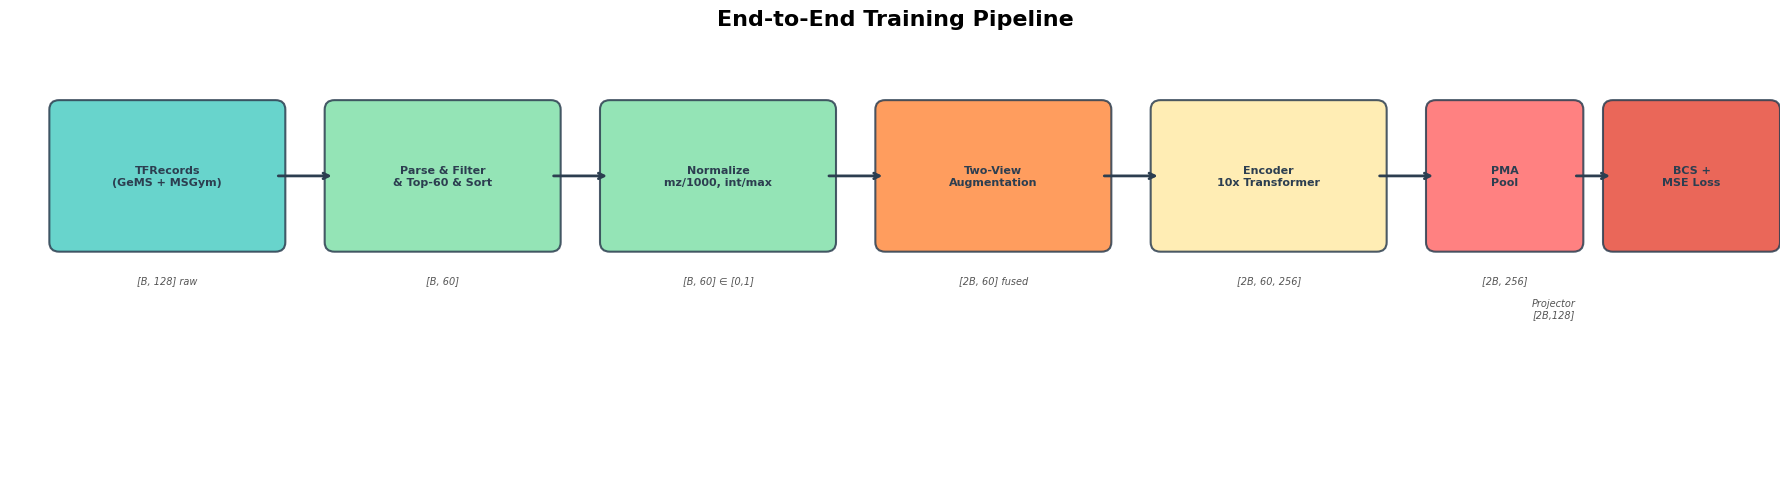

In [2]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_xlim(-0.5, 17.5)
ax.set_ylim(-1.5, 3)
ax.axis("off")
ax.set_title("End-to-End Training Pipeline", fontsize=16, fontweight="bold", pad=20)

boxes = [
    (0,  1, 2.2, 1.4, C["data"],     "TFRecords\n(GeMS + MSGym)",     8),
    (2.8, 1, 2.2, 1.4, C["pipeline"], "Parse & Filter\n& Top-60 & Sort", 8),
    (5.6, 1, 2.2, 1.4, C["pipeline"], "Normalize\nmz/1000, int/max",  8),
    (8.4, 1, 2.2, 1.4, C["aug_v1"],   "Two-View\nAugmentation",       8),
    (11.2, 1, 2.2, 1.4, C["encoder"], "Encoder\n10x Transformer",     8),
    (14, 1, 1.4, 1.4, C["pool"],      "PMA\nPool",                    8),
    (15.8, 1, 1.6, 1.4, C["loss"],    "BCS +\nMSE Loss",             8),
]

for x, y, w, h, color, label, fs in boxes:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor="#2C3E50", linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fs, fontweight="bold", color="#2C3E50")

# Arrows
arrow_xs = [(2.2, 2.8), (5.0, 5.6), (7.8, 8.4), (10.6, 11.2), (13.4, 14.0), (15.4, 15.8)]
for x1, x2 in arrow_xs:
    ax.annotate("", xy=(x2, 1.7), xytext=(x1, 1.7),
                arrowprops=dict(arrowstyle="->", lw=2, color="#2C3E50"))

# Shape annotations below
shapes = [
    (1.1, 0.6,  "[B, 128] raw"),
    (3.9, 0.6,  "[B, 60]"),
    (6.7, 0.6,  "[B, 60] \u2208 [0,1]"),
    (9.5, 0.6,  "[2B, 60] fused"),
    (12.3, 0.6, "[2B, 60, 256]"),
    (14.7, 0.6, "[2B, 256]"),
]
for x, y, txt in shapes:
    ax.text(x, y, txt, ha="center", va="center", fontsize=7,
            style="italic", color="#555")

# Sub-label: Projector between Pool and Loss
ax.text(15.2, 0.3, "Projector\n[2B,128]", ha="center", va="center",
        fontsize=7, style="italic", color="#555")

plt.tight_layout()
plt.show()

---
## 2. Data Pipeline Detail

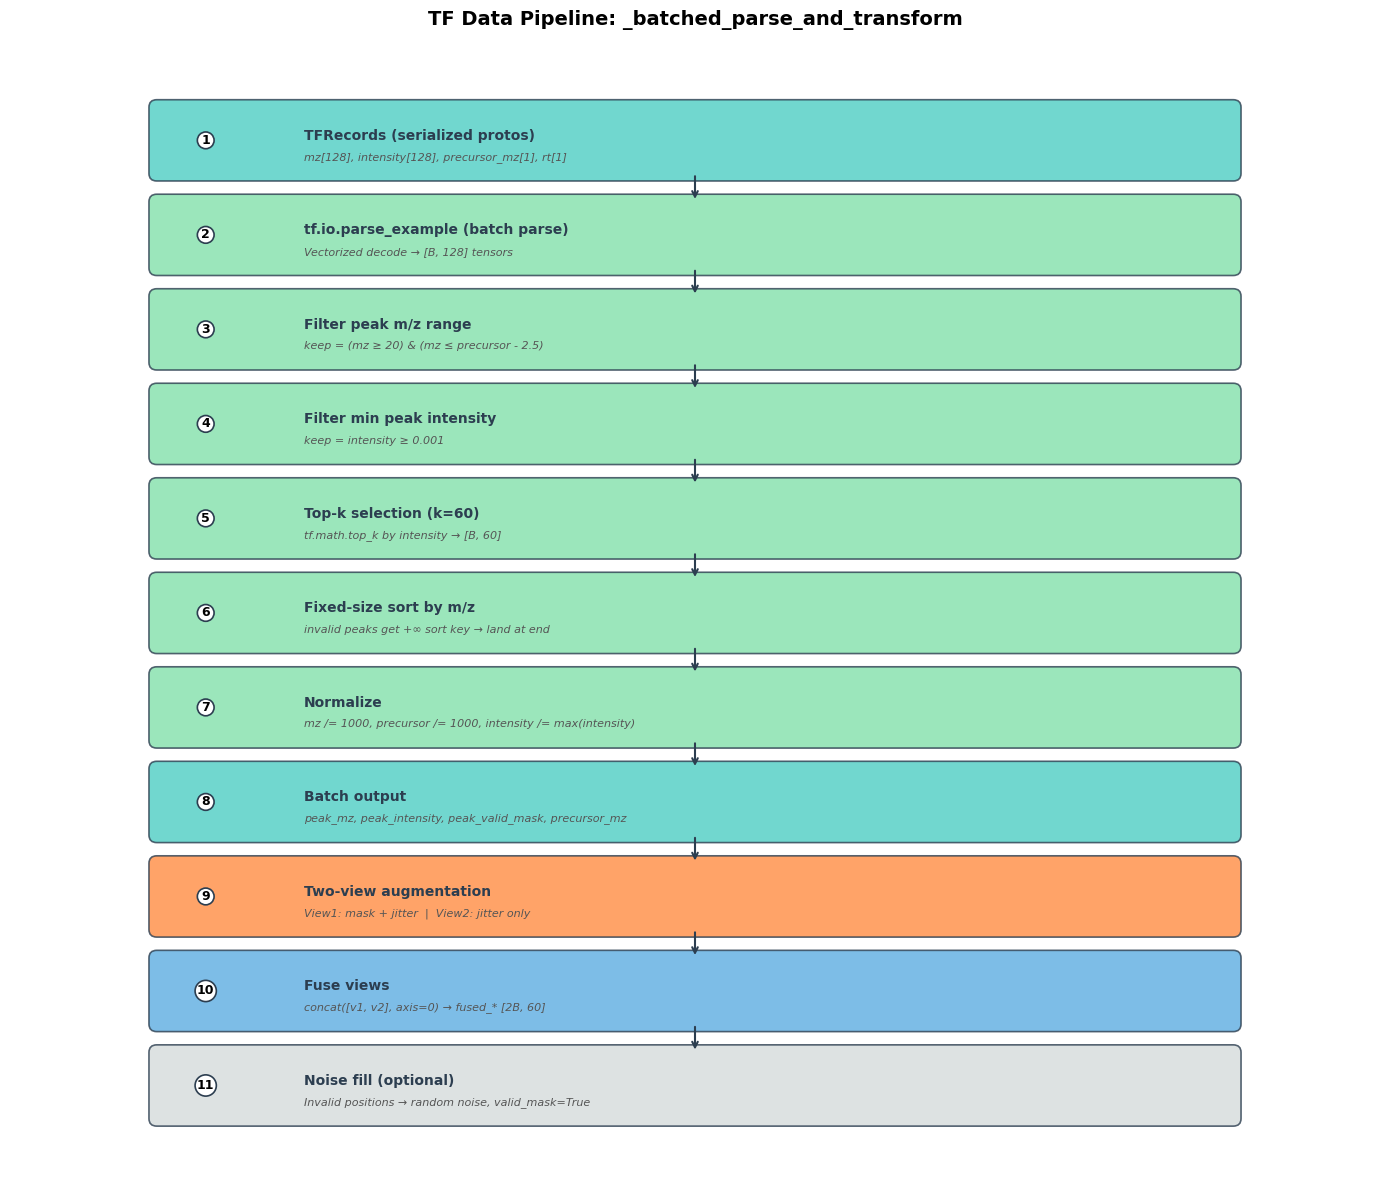

In [3]:
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis("off")
ax.set_title("TF Data Pipeline: _batched_parse_and_transform",
             fontsize=14, fontweight="bold", pad=15)

steps = [
    (11.0, "TFRecords (serialized protos)", "mz[128], intensity[128], precursor_mz[1], rt[1]", C["data"]),
    (10.0, "tf.io.parse_example (batch parse)", "Vectorized decode \u2192 [B, 128] tensors", C["pipeline"]),
    (9.0,  "Filter peak m/z range", "keep = (mz \u2265 20) & (mz \u2264 precursor - 2.5)", C["pipeline"]),
    (8.0,  "Filter min peak intensity", "keep = intensity \u2265 0.001", C["pipeline"]),
    (7.0,  "Top-k selection (k=60)", "tf.math.top_k by intensity \u2192 [B, 60]", C["pipeline"]),
    (6.0,  "Fixed-size sort by m/z", "invalid peaks get +\u221e sort key \u2192 land at end", C["pipeline"]),
    (5.0,  "Normalize", "mz /= 1000, precursor /= 1000, intensity /= max(intensity)", C["pipeline"]),
    (4.0,  "Batch output", "peak_mz, peak_intensity, peak_valid_mask, precursor_mz", C["data"]),
    (3.0,  "Two-view augmentation", "View1: mask + jitter  |  View2: jitter only", C["aug_v1"]),
    (2.0,  "Fuse views", "concat([v1, v2], axis=0) \u2192 fused_* [2B, 60]", C["aug_v2"]),
    (1.0,  "Noise fill (optional)", "Invalid positions \u2192 random noise, valid_mask=True", C["norm"]),
]

for y, title, desc, color in steps:
    box = FancyBboxPatch((1.5, y - 0.35), 11, 0.7, boxstyle="round,pad=0.08",
                         facecolor=color, edgecolor="#2C3E50", linewidth=1.2, alpha=0.8)
    ax.add_patch(box)
    ax.text(3.0, y + 0.05, title, fontsize=10, fontweight="bold", va="center", color="#2C3E50")
    ax.text(3.0, y - 0.18, desc, fontsize=8, va="center", color="#555", style="italic")

# Arrows between steps
for i in range(len(steps) - 1):
    y_from = steps[i][0] - 0.35
    y_to = steps[i + 1][0] + 0.35
    ax.annotate("", xy=(7, y_to), xytext=(7, y_from),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))

# Step numbers
for i, (y, *_) in enumerate(steps):
    ax.text(2.0, y, str(i + 1), fontsize=9, fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="circle,pad=0.15", fc="white", ec="#2C3E50", lw=1.2))

plt.tight_layout()
plt.show()

---
## 3. Two-View Augmentation Strategy

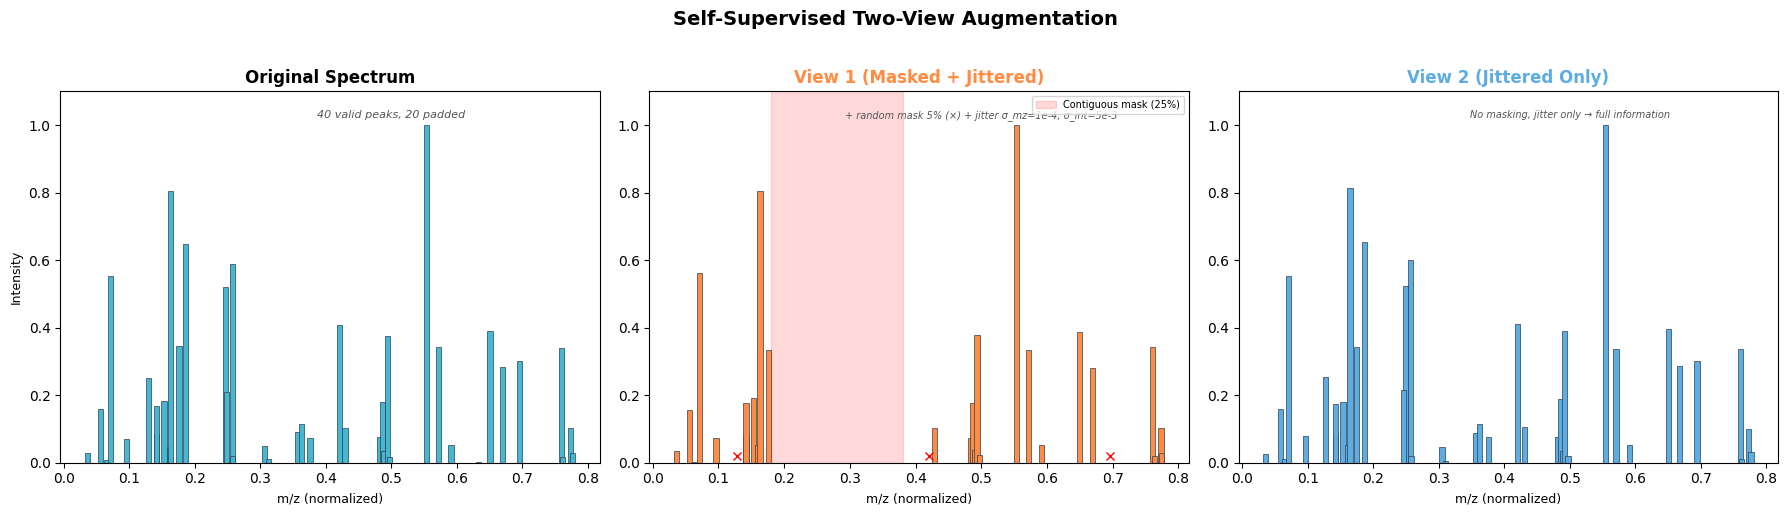

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
np.random.seed(42)

N = 60
valid = 40
mz = np.sort(np.random.uniform(0.02, 0.8, valid))
intensity = np.random.exponential(0.3, valid)
intensity = intensity / intensity.max()

# ── Original spectrum ──
ax = axes[0]
ax.set_title("Original Spectrum", fontsize=12, fontweight="bold")
colors_orig = [C["fourier"]] * valid
ax.bar(mz, intensity, width=0.008, color=colors_orig, edgecolor="#2C3E50", linewidth=0.5)
ax.axhline(y=0, color="#ccc", linewidth=0.5)
ax.set_xlabel("m/z (normalized)", fontsize=9)
ax.set_ylabel("Intensity", fontsize=9)
ax.set_ylim(0, 1.1)
ax.text(0.5, 1.02, f"{valid} valid peaks, {N-valid} padded",
        ha="center", fontsize=8, color="#555", style="italic")

# ── View 1: Masked + Jittered ──
ax = axes[1]
ax.set_title("View 1 (Masked + Jittered)", fontsize=12, fontweight="bold", color=C["aug_v1"])
mask_start = 12
mask_len = 10  # 25% of 40
random_masked = {5, 22, 35}  # 5% random
colors_v1 = []
mz_v1 = mz.copy()
int_v1 = intensity.copy()
for i in range(valid):
    if mask_start <= i < mask_start + mask_len or i in random_masked:
        colors_v1.append("#DDDDDD")
        int_v1[i] = 0
    else:
        colors_v1.append(C["aug_v1"])
        mz_v1[i] += np.random.normal(0, 0.001)
        int_v1[i] = max(0, int_v1[i] + np.random.normal(0, 0.005))
int_v1_norm = int_v1 / (int_v1.max() + 1e-8)

ax.bar(mz_v1, int_v1_norm, width=0.008, color=colors_v1, edgecolor="#2C3E50", linewidth=0.5)
ax.axhline(y=0, color="#ccc", linewidth=0.5)
# Highlight masked region
ax.axvspan(mz[mask_start] - 0.005, mz[mask_start + mask_len - 1] + 0.005,
           alpha=0.15, color="red", label="Contiguous mask (25%)")
for i in random_masked:
    if i < valid:
        ax.plot(mz[i], 0.02, "x", color="red", markersize=6)
ax.set_xlabel("m/z (normalized)", fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=7, loc="upper right")
ax.text(0.5, 1.02, "+ random mask 5% (\u00d7) + jitter \u03c3_mz=1e-4, \u03c3_int=5e-3",
        ha="center", fontsize=7, color="#555", style="italic")

# ── View 2: Jittered only ──
ax = axes[2]
ax.set_title("View 2 (Jittered Only)", fontsize=12, fontweight="bold", color=C["aug_v2"])
mz_v2 = mz + np.random.normal(0, 0.001, valid)
int_v2 = np.maximum(0, intensity + np.random.normal(0, 0.005, valid))
int_v2 = int_v2 / int_v2.max()
ax.bar(mz_v2, int_v2, width=0.008, color=C["aug_v2"], edgecolor="#2C3E50", linewidth=0.5)
ax.axhline(y=0, color="#ccc", linewidth=0.5)
ax.set_xlabel("m/z (normalized)", fontsize=9)
ax.set_ylim(0, 1.1)
ax.text(0.5, 1.02, "No masking, jitter only \u2192 full information",
        ha="center", fontsize=7, color="#555", style="italic")

plt.suptitle("Self-Supervised Two-View Augmentation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. PeakFeatureEmbedder: Fourier Encoding + Neutral Loss

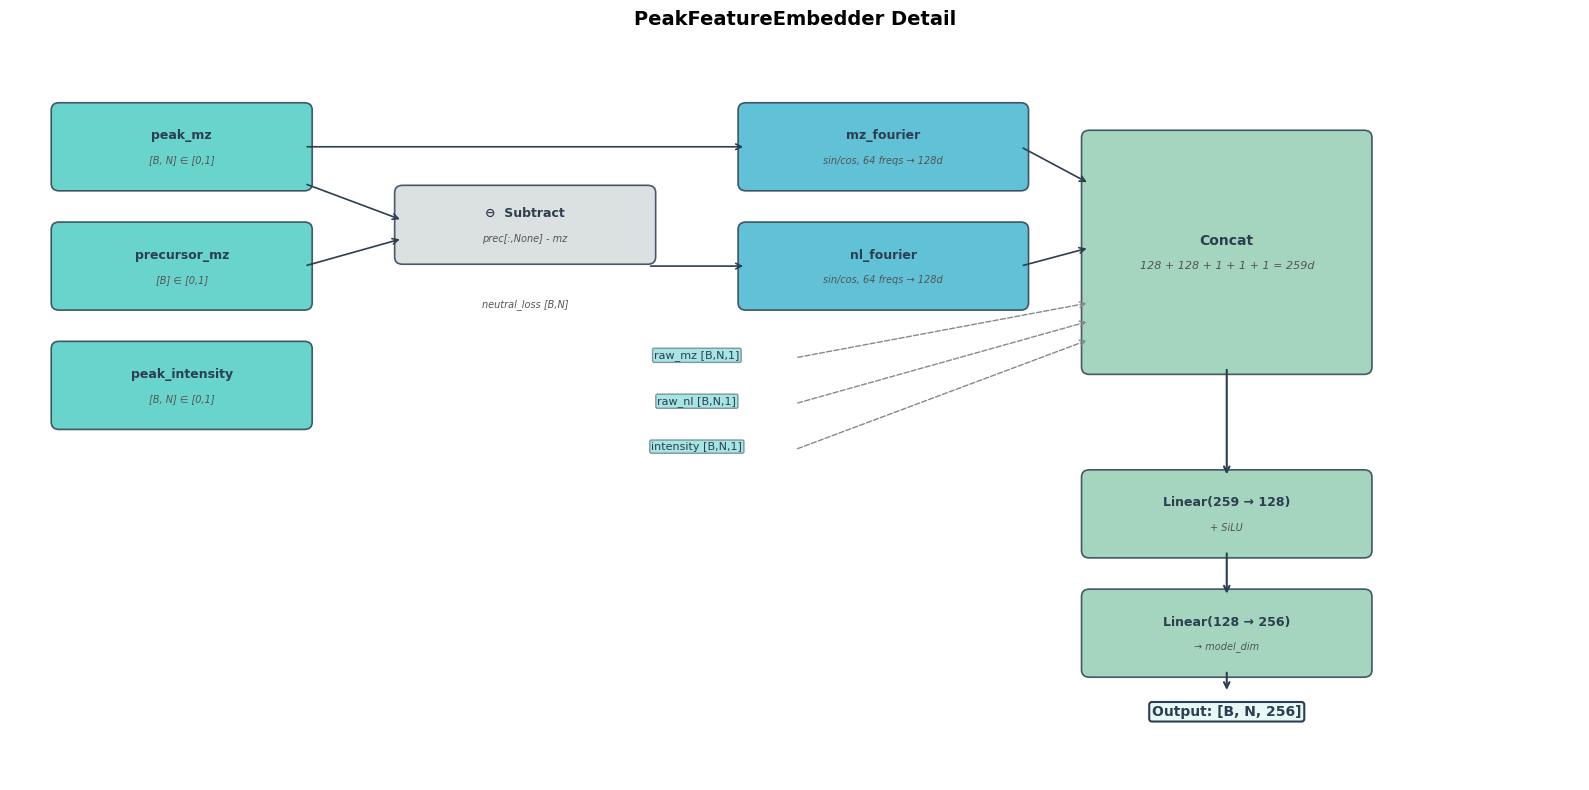

In [5]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("PeakFeatureEmbedder Detail", fontsize=14, fontweight="bold", pad=15)

def draw_box(ax, x, y, w, h, color, label, sublabel="", fs=9):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                         facecolor=color, edgecolor="#2C3E50", linewidth=1.2, alpha=0.85)
    ax.add_patch(box)
    if sublabel:
        ax.text(x + w/2, y + h/2 + 0.12, label, ha="center", va="center",
                fontsize=fs, fontweight="bold", color="#2C3E50")
        ax.text(x + w/2, y + h/2 - 0.15, sublabel, ha="center", va="center",
                fontsize=fs - 2, color="#555", style="italic")
    else:
        ax.text(x + w/2, y + h/2, label, ha="center", va="center",
                fontsize=fs, fontweight="bold", color="#2C3E50")

# ── Inputs (left column) ──
draw_box(ax, 0.5, 6.5, 2.5, 0.8, C["data"], "peak_mz", "[B, N] \u2208 [0,1]")
draw_box(ax, 0.5, 5.2, 2.5, 0.8, C["data"], "precursor_mz", "[B] \u2208 [0,1]")
draw_box(ax, 0.5, 3.9, 2.5, 0.8, C["data"], "peak_intensity", "[B, N] \u2208 [0,1]")

# ── Neutral loss computation ──
draw_box(ax, 4.0, 5.7, 2.5, 0.7, C["norm"], "\u2296  Subtract", "prec[:,None] - mz")
ax.annotate("", xy=(4.0, 6.1), xytext=(3.0, 6.5),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(4.0, 5.9), xytext=(3.0, 5.6),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.text(5.25, 5.15, "neutral_loss [B,N]", fontsize=7, ha="center", color="#555", style="italic")

# ── Fourier encodings ──
draw_box(ax, 7.5, 6.5, 2.8, 0.8, C["fourier"], "mz_fourier", "sin/cos, 64 freqs \u2192 128d")
draw_box(ax, 7.5, 5.2, 2.8, 0.8, C["fourier"], "nl_fourier", "sin/cos, 64 freqs \u2192 128d")

# Arrows: mz -> mz_fourier
ax.annotate("", xy=(7.5, 6.9), xytext=(3.0, 6.9),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
# Arrows: neutral_loss -> nl_fourier
ax.annotate("", xy=(7.5, 5.6), xytext=(6.5, 5.6),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# ── Raw features pass-through ──
ax.text(7.0, 4.6, "raw_mz [B,N,1]", fontsize=8, ha="center", color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.15", fc=C["data"], ec="#2C3E50", alpha=0.5))
ax.text(7.0, 4.1, "raw_nl [B,N,1]", fontsize=8, ha="center", color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.15", fc=C["data"], ec="#2C3E50", alpha=0.5))
ax.text(7.0, 3.6, "intensity [B,N,1]", fontsize=8, ha="center", color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.15", fc=C["data"], ec="#2C3E50", alpha=0.5))

# ── Concatenation ──
draw_box(ax, 11.0, 4.5, 2.8, 2.5, C["embed"], "Concat", "128 + 128 + 1 + 1 + 1 = 259d", fs=10)

# Arrows into concat
ax.annotate("", xy=(11.0, 6.5), xytext=(10.3, 6.9),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(11.0, 5.8), xytext=(10.3, 5.6),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(11.0, 5.2), xytext=(8.0, 4.6),
            arrowprops=dict(arrowstyle="->", lw=1.0, color="#888", ls="--"))
ax.annotate("", xy=(11.0, 5.0), xytext=(8.0, 4.1),
            arrowprops=dict(arrowstyle="->", lw=1.0, color="#888", ls="--"))
ax.annotate("", xy=(11.0, 4.8), xytext=(8.0, 3.6),
            arrowprops=dict(arrowstyle="->", lw=1.0, color="#888", ls="--"))

# ── MLP ──
draw_box(ax, 11.0, 2.5, 2.8, 0.8, C["embed"], "Linear(259 \u2192 128)", "+ SiLU")
draw_box(ax, 11.0, 1.2, 2.8, 0.8, C["embed"], "Linear(128 \u2192 256)", "\u2192 model_dim")

ax.annotate("", xy=(12.4, 3.3), xytext=(12.4, 4.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))
ax.annotate("", xy=(12.4, 2.0), xytext=(12.4, 2.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))

# Output label
ax.text(12.4, 0.7, "Output: [B, N, 256]", ha="center", fontsize=10,
        fontweight="bold", color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.2", fc="#E8F8F5", ec="#2C3E50", lw=1.5))
ax.annotate("", xy=(12.4, 0.95), xytext=(12.4, 1.2),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))

plt.tight_layout()
plt.show()

---
## 5. Fourier Features Frequency Response

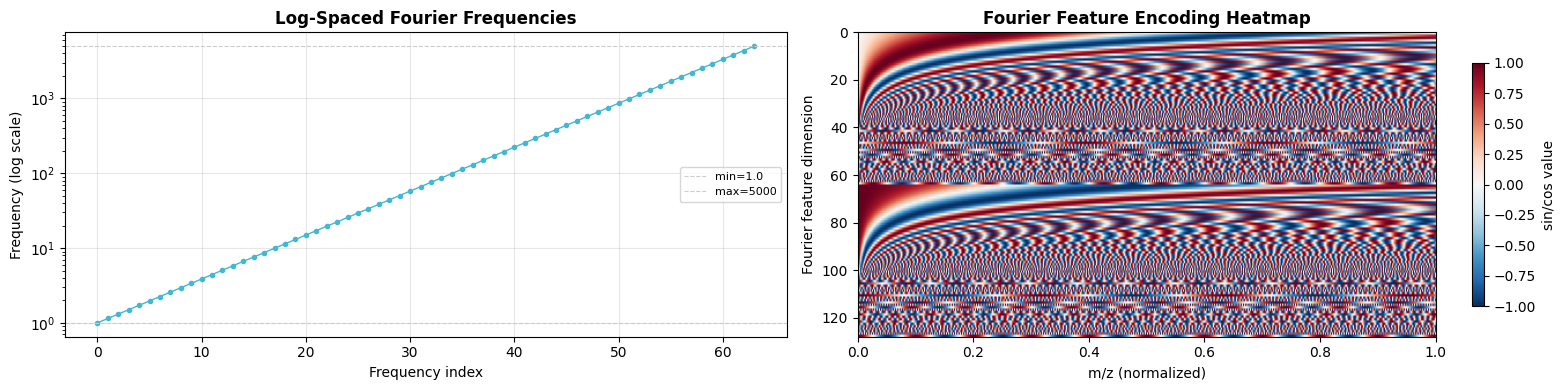

In [6]:
import torch, sys, math
sys.path.insert(0, "..")
from models.model import FourierFeatures

ff = FourierFeatures(num_frequencies=64, min_freq=1.0, max_freq=5000.0)

x = torch.linspace(0, 1, 500)
with torch.no_grad():
    encoded = ff(x.unsqueeze(0)).squeeze(0)  # [500, 128]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: log-spaced frequencies
freqs = ff.freqs.numpy()
ax = axes[0]
ax.semilogy(range(len(freqs)), freqs, "o-", color=C["fourier"], markersize=3, linewidth=1)
ax.set_xlabel("Frequency index")
ax.set_ylabel("Frequency (log scale)")
ax.set_title("Log-Spaced Fourier Frequencies", fontweight="bold")
ax.axhline(y=1.0, color="#ccc", ls="--", lw=0.8, label="min=1.0")
ax.axhline(y=5000.0, color="#ccc", ls="--", lw=0.8, label="max=5000")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: heatmap of encodings
ax = axes[1]
im = ax.imshow(encoded.numpy().T, aspect="auto", cmap="RdBu_r",
               extent=[0, 1, 128, 0], vmin=-1, vmax=1)
ax.set_xlabel("m/z (normalized)")
ax.set_ylabel("Fourier feature dimension")
ax.set_title("Fourier Feature Encoding Heatmap", fontweight="bold")
plt.colorbar(im, ax=ax, label="sin/cos value", shrink=0.8)

plt.tight_layout()
plt.show()

---
## 6. Full Model Architecture: PeakSetSIGReg

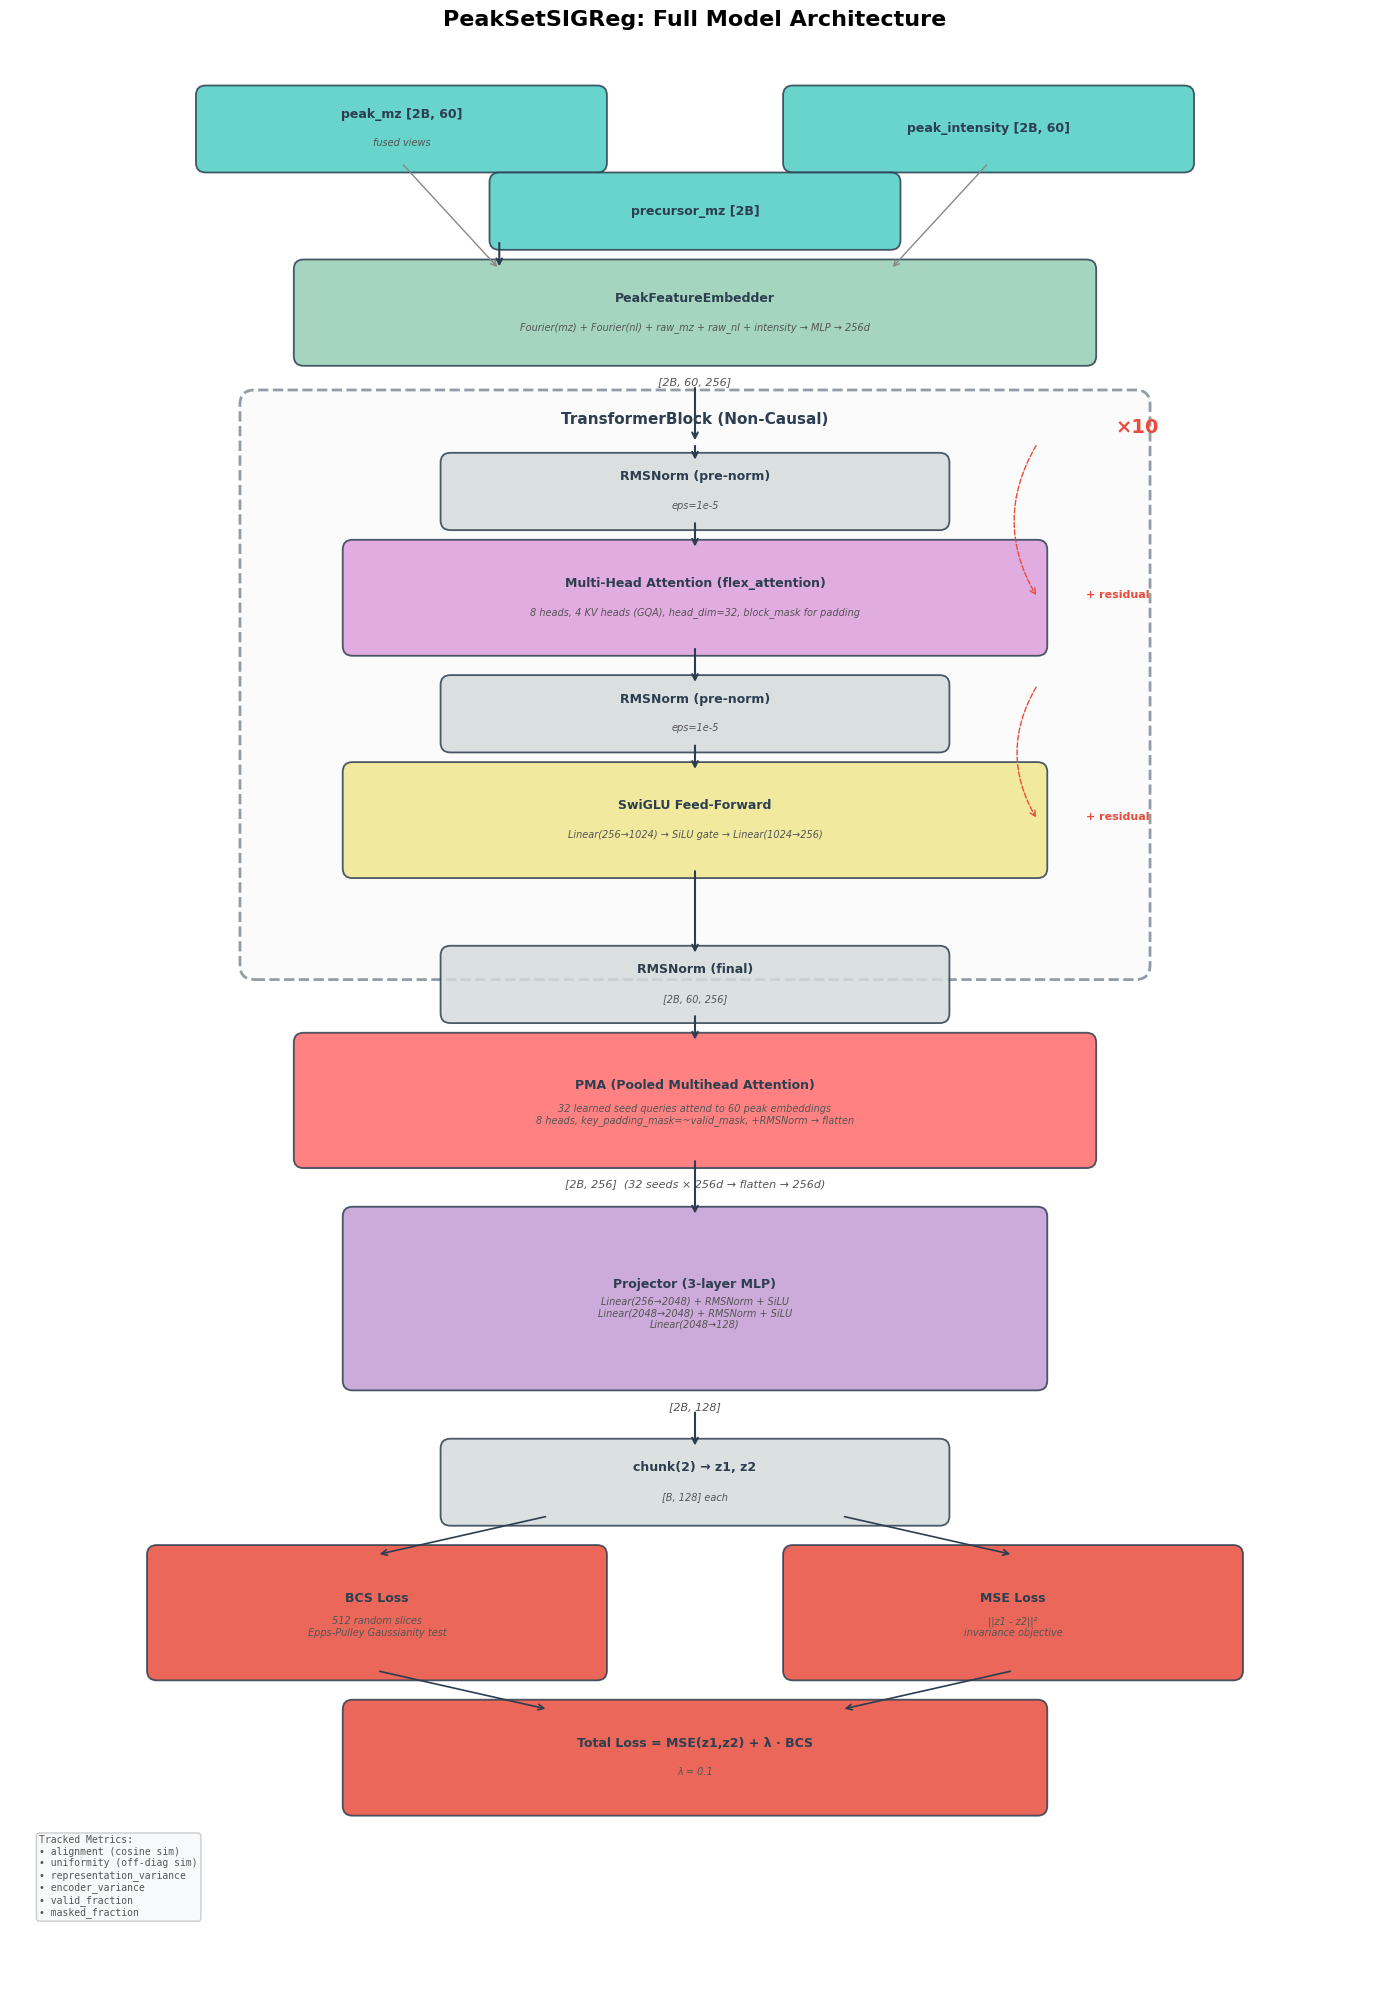

In [7]:
fig, ax = plt.subplots(figsize=(14, 20))
ax.set_xlim(0, 14)
ax.set_ylim(0, 20)
ax.axis("off")
ax.set_title("PeakSetSIGReg: Full Model Architecture",
             fontsize=16, fontweight="bold", pad=15)

def block(ax, x, y, w, h, color, title, sub="", fs=9):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                       facecolor=color, edgecolor="#2C3E50", linewidth=1.3, alpha=0.85)
    ax.add_patch(b)
    if sub:
        ax.text(x+w/2, y+h/2+0.15, title, ha="center", va="center",
                fontsize=fs, fontweight="bold", color="#2C3E50")
        ax.text(x+w/2, y+h/2-0.15, sub, ha="center", va="center",
                fontsize=fs-2, color="#555", style="italic")
    else:
        ax.text(x+w/2, y+h/2, title, ha="center", va="center",
                fontsize=fs, fontweight="bold", color="#2C3E50")

def arrow_down(ax, x, y_from, y_to):
    ax.annotate("", xy=(x, y_to), xytext=(x, y_from),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))

cx = 7  # centre x

# ── INPUTS ──
block(ax, 2, 18.8, 4, 0.7, C["data"], "peak_mz [2B, 60]", "fused views")
block(ax, 8, 18.8, 4, 0.7, C["data"], "peak_intensity [2B, 60]")
block(ax, 5, 18.0, 4, 0.6, C["data"], "precursor_mz [2B]")

# ── EMBEDDER ──
block(ax, 3, 16.8, 8, 0.9, C["embed"],
      "PeakFeatureEmbedder",
      "Fourier(mz) + Fourier(nl) + raw_mz + raw_nl + intensity \u2192 MLP \u2192 256d")
arrow_down(ax, 5, 18.0, 17.7)
ax.annotate("", xy=(5, 17.7), xytext=(4, 18.8),
            arrowprops=dict(arrowstyle="->", lw=1, color="#888"))
ax.annotate("", xy=(9, 17.7), xytext=(10, 18.8),
            arrowprops=dict(arrowstyle="->", lw=1, color="#888"))

ax.text(cx, 16.5, "[2B, 60, 256]", ha="center", fontsize=8, color="#555", style="italic")

# ── TRANSFORMER BLOCKS (x10) ──
# Draw a big container
container = FancyBboxPatch((2.5, 10.5), 9, 5.8, boxstyle="round,pad=0.15",
                            facecolor=C["bg_block"], edgecolor="#2C3E50",
                            linewidth=2, linestyle="--", alpha=0.5)
ax.add_patch(container)
ax.text(11.3, 16.0, "\u00d710", fontsize=14, fontweight="bold", color="#E74C3C")
ax.text(cx, 16.1, "TransformerBlock (Non-Causal)", ha="center",
        fontsize=11, fontweight="bold", color="#2C3E50")

# Inside the block:
arrow_down(ax, cx, 16.5, 15.9)

# RMSNorm 1
block(ax, 4.5, 15.1, 5, 0.6, C["norm"], "RMSNorm (pre-norm)", "eps=1e-5")
arrow_down(ax, cx, 15.9, 15.7)

# Attention
block(ax, 3.5, 13.8, 7, 1.0, C["attn"],
      "Multi-Head Attention (flex_attention)",
      "8 heads, 4 KV heads (GQA), head_dim=32, block_mask for padding")
arrow_down(ax, cx, 15.1, 14.8)

# Residual 1
ax.text(11.0, 14.3, "+ residual", fontsize=8, color="#E74C3C", fontweight="bold")
ax.annotate("", xy=(10.5, 14.3), xytext=(10.5, 15.9),
            arrowprops=dict(arrowstyle="->", lw=1, color="#E74C3C", ls="--",
                           connectionstyle="arc3,rad=0.3"))

# RMSNorm 2
block(ax, 4.5, 12.8, 5, 0.6, C["norm"], "RMSNorm (pre-norm)", "eps=1e-5")
arrow_down(ax, cx, 13.8, 13.4)

# FFN
block(ax, 3.5, 11.5, 7, 1.0, C["ffn"],
      "SwiGLU Feed-Forward",
      "Linear(256\u21921024) \u2192 SiLU gate \u2192 Linear(1024\u2192256)")
arrow_down(ax, cx, 12.8, 12.5)

# Residual 2
ax.text(11.0, 12.0, "+ residual", fontsize=8, color="#E74C3C", fontweight="bold")
ax.annotate("", xy=(10.5, 12.0), xytext=(10.5, 13.4),
            arrowprops=dict(arrowstyle="->", lw=1, color="#E74C3C", ls="--",
                           connectionstyle="arc3,rad=0.3"))

# Final RMSNorm
block(ax, 4.5, 10.0, 5, 0.6, C["norm"], "RMSNorm (final)", "[2B, 60, 256]")
arrow_down(ax, cx, 11.5, 10.6)

# ── PMA POOLING ──
block(ax, 3, 8.5, 8, 1.2, C["pool"],
      "PMA (Pooled Multihead Attention)",
      "32 learned seed queries attend to 60 peak embeddings\n"
      "8 heads, key_padding_mask=~valid_mask, +RMSNorm \u2192 flatten")
arrow_down(ax, cx, 10.0, 9.7)
ax.text(cx, 8.2, "[2B, 256]  (32 seeds \u00d7 256d \u2192 flatten \u2192 256d)",
        ha="center", fontsize=8, color="#555", style="italic")

# ── PROJECTOR ──
block(ax, 3.5, 6.2, 7, 1.7, C["proj"],
      "Projector (3-layer MLP)",
      "Linear(256\u21922048) + RMSNorm + SiLU\n"
      "Linear(2048\u21922048) + RMSNorm + SiLU\n"
      "Linear(2048\u2192128)")
arrow_down(ax, cx, 8.5, 7.9)
ax.text(cx, 5.9, "[2B, 128]", ha="center", fontsize=8, color="#555", style="italic")

# ── SPLIT ──
block(ax, 4.5, 4.8, 5, 0.7, C["norm"], "chunk(2) \u2192 z1, z2", "[B, 128] each")
arrow_down(ax, cx, 5.9, 5.5)

# ── LOSSES ──
block(ax, 1.5, 3.2, 4.5, 1.2, C["loss"],
      "BCS Loss",
      "512 random slices\nEpps-Pulley Gaussianity test")
block(ax, 8, 3.2, 4.5, 1.2, C["loss"],
      "MSE Loss",
      "||z1 - z2||\u00b2\ninvariance objective")

ax.annotate("", xy=(3.75, 4.4), xytext=(5.5, 4.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(10.25, 4.4), xytext=(8.5, 4.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# ── COMBINED LOSS ──
block(ax, 3.5, 1.8, 7, 1.0, C["loss"],
      "Total Loss = MSE(z1,z2) + \u03bb \u00b7 BCS",
      "\u03bb = 0.1")
ax.annotate("", xy=(5.5, 2.8), xytext=(3.75, 3.2),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(8.5, 2.8), xytext=(10.25, 3.2),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# Metrics sidebar
metrics_text = (
    "Tracked Metrics:\n"
    "\u2022 alignment (cosine sim)\n"
    "\u2022 uniformity (off-diag sim)\n"
    "\u2022 representation_variance\n"
    "\u2022 encoder_variance\n"
    "\u2022 valid_fraction\n"
    "\u2022 masked_fraction"
)
ax.text(0.3, 1.5, metrics_text, fontsize=7, color="#555",
        verticalalignment="top", family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", fc="#F8F9FA", ec="#CCC"))

plt.tight_layout()
plt.show()

---
## 7. Transformer Block Internals

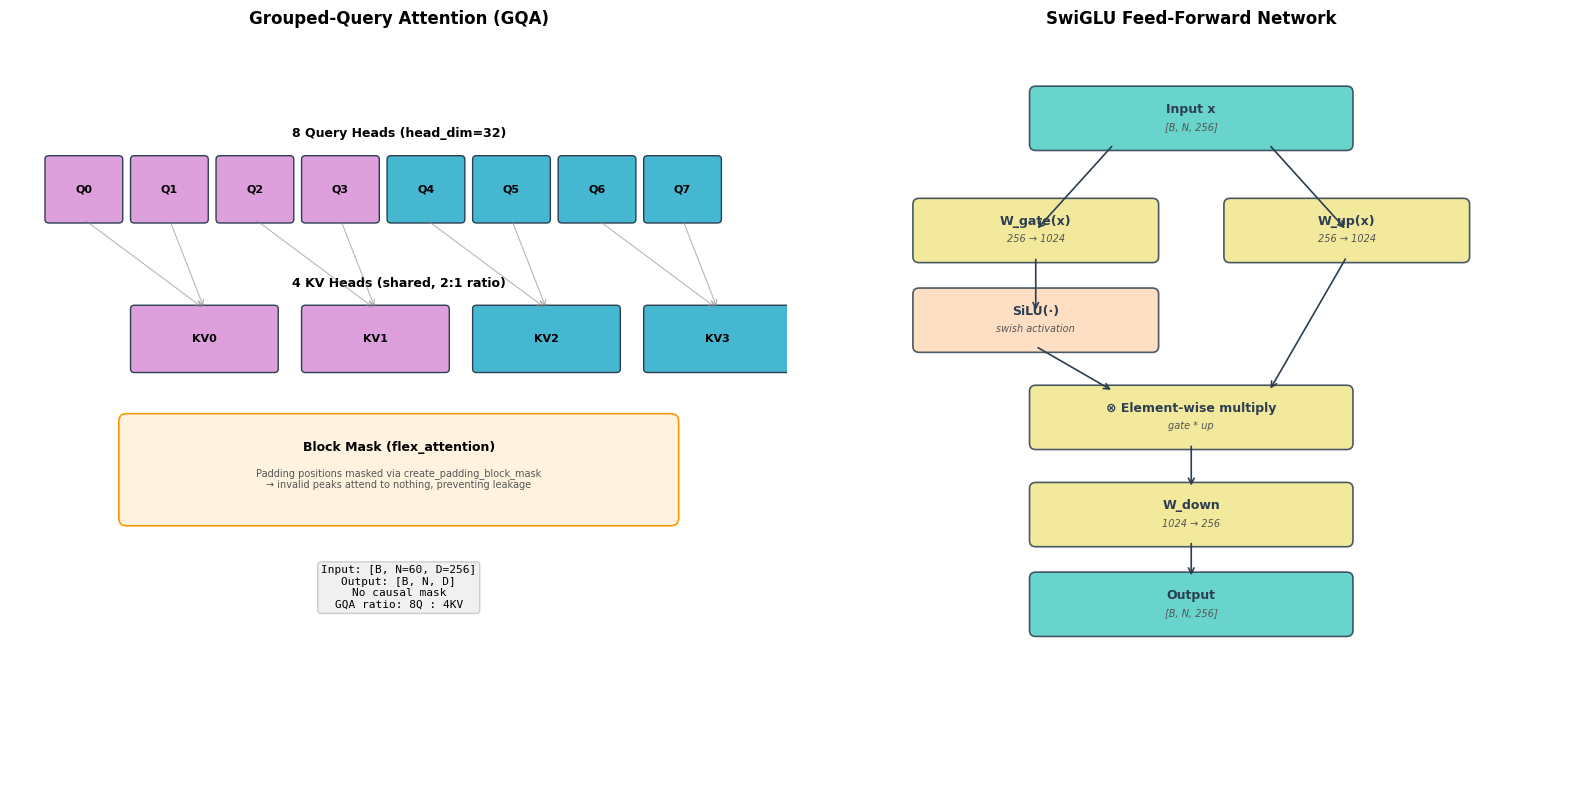

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Left: GQA Attention Detail ──
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Grouped-Query Attention (GQA)", fontsize=12, fontweight="bold")

# Query heads (8)
for i in range(8):
    color = C["attn"] if i < 4 else C["fourier"]
    rect = FancyBboxPatch((0.5 + i * 1.1, 7.5), 0.9, 0.8,
                          boxstyle="round,pad=0.05", fc=color, ec="#2C3E50", lw=1)
    ax.add_patch(rect)
    ax.text(0.95 + i * 1.1, 7.9, f"Q{i}", ha="center", va="center", fontsize=8, fontweight="bold")
ax.text(5, 8.6, "8 Query Heads (head_dim=32)", ha="center", fontsize=9, fontweight="bold")

# KV heads (4)
for i in range(4):
    color = C["attn"] if i < 2 else C["fourier"]
    rect = FancyBboxPatch((1.6 + i * 2.2, 5.5), 1.8, 0.8,
                          boxstyle="round,pad=0.05", fc=color, ec="#2C3E50", lw=1)
    ax.add_patch(rect)
    ax.text(2.5 + i * 2.2, 5.9, f"KV{i}", ha="center", va="center", fontsize=8, fontweight="bold")
ax.text(5, 6.6, "4 KV Heads (shared, 2:1 ratio)", ha="center", fontsize=9, fontweight="bold")

# Arrows showing grouping
for i in range(8):
    kv_idx = i // 2
    ax.annotate("", xy=(2.5 + kv_idx * 2.2, 6.3), xytext=(0.95 + i * 1.1, 7.5),
                arrowprops=dict(arrowstyle="->", lw=0.8, color="#888", alpha=0.6))

# Block mask note
block_mask_box = FancyBboxPatch((1.5, 3.5), 7, 1.3, boxstyle="round,pad=0.1",
                                fc="#FFF3E0", ec="#FF9800", lw=1.2)
ax.add_patch(block_mask_box)
ax.text(5, 4.4, "Block Mask (flex_attention)", ha="center", fontsize=9, fontweight="bold")
ax.text(5, 3.9, "Padding positions masked via create_padding_block_mask\n"
        "\u2192 invalid peaks attend to nothing, preventing leakage",
        ha="center", fontsize=7, color="#555")

# Info box
info = "Input: [B, N=60, D=256]\nOutput: [B, N, D]\nNo causal mask\nGQA ratio: 8Q : 4KV"
ax.text(5, 2.3, info, ha="center", fontsize=8, family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", fc="#F0F0F0", ec="#CCC"))

# ── Right: SwiGLU FFN Detail ──
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("SwiGLU Feed-Forward Network", fontsize=12, fontweight="bold")

def ffn_block(ax, x, y, w, h, color, text, sub=""):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                       fc=color, ec="#2C3E50", lw=1.2, alpha=0.85)
    ax.add_patch(b)
    if sub:
        ax.text(x+w/2, y+h/2+0.12, text, ha="center", va="center",
                fontsize=9, fontweight="bold", color="#2C3E50")
        ax.text(x+w/2, y+h/2-0.12, sub, ha="center", va="center",
                fontsize=7, color="#555", style="italic")
    else:
        ax.text(x+w/2, y+h/2, text, ha="center", va="center",
                fontsize=9, fontweight="bold", color="#2C3E50")

ffn_block(ax, 3, 8.5, 4, 0.7, C["data"], "Input x", "[B, N, 256]")
ffn_block(ax, 1.5, 7.0, 3, 0.7, C["ffn"], "W_gate(x)", "256 \u2192 1024")
ffn_block(ax, 5.5, 7.0, 3, 0.7, C["ffn"], "W_up(x)", "256 \u2192 1024")
ffn_block(ax, 1.5, 5.8, 3, 0.7, "#FFDAB9", "SiLU(\u00b7)", "swish activation")
ffn_block(ax, 3, 4.5, 4, 0.7, C["ffn"], "\u2297 Element-wise multiply", "gate * up")
ffn_block(ax, 3, 3.2, 4, 0.7, C["ffn"], "W_down", "1024 \u2192 256")
ffn_block(ax, 3, 2.0, 4, 0.7, C["data"], "Output", "[B, N, 256]")

# Arrows
ax.annotate("", xy=(3, 7.35), xytext=(4, 8.5),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(7, 7.35), xytext=(6, 8.5),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(3, 6.25), xytext=(3, 7.0),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(4, 5.2), xytext=(3, 5.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(6, 5.2), xytext=(7, 7.0),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(5, 3.9), xytext=(5, 4.5),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(5, 2.7), xytext=(5, 3.2),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

plt.tight_layout()
plt.show()

---
## 8. BCS Loss: Batched Characteristic Slicing

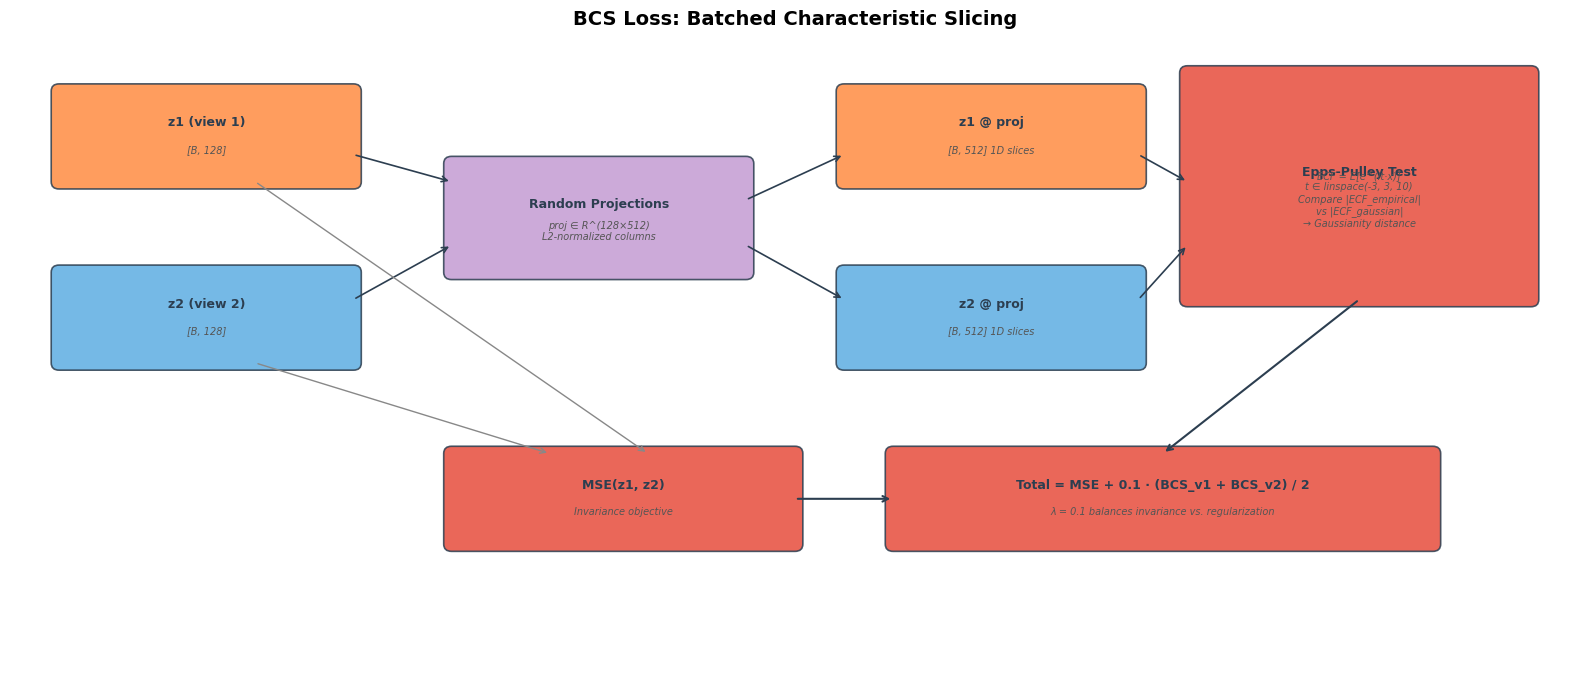

In [9]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis("off")
ax.set_title("BCS Loss: Batched Characteristic Slicing", fontsize=14, fontweight="bold", pad=15)

def bcs_box(ax, x, y, w, h, color, title, sub=""):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                       fc=color, ec="#2C3E50", lw=1.2, alpha=0.85)
    ax.add_patch(b)
    if sub:
        ax.text(x+w/2, y+h/2+0.15, title, ha="center", va="center",
                fontsize=9, fontweight="bold", color="#2C3E50")
        ax.text(x+w/2, y+h/2-0.15, sub, ha="center", va="center",
                fontsize=7, color="#555", style="italic")
    else:
        ax.text(x+w/2, y+h/2, title, ha="center", va="center",
                fontsize=9, fontweight="bold", color="#2C3E50")

# Input representations
bcs_box(ax, 0.5, 5.5, 3, 1, C["aug_v1"], "z1 (view 1)", "[B, 128]")
bcs_box(ax, 0.5, 3.5, 3, 1, C["aug_v2"], "z2 (view 2)", "[B, 128]")

# Random projection
bcs_box(ax, 4.5, 4.5, 3, 1.2, C["proj"],
        "Random Projections",
        "proj \u2208 R^(128\u00d7512)\nL2-normalized columns")

ax.annotate("", xy=(4.5, 5.5), xytext=(3.5, 5.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(4.5, 4.8), xytext=(3.5, 4.2),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# Sliced projections
bcs_box(ax, 8.5, 5.5, 3, 1, C["aug_v1"], "z1 @ proj", "[B, 512] 1D slices")
bcs_box(ax, 8.5, 3.5, 3, 1, C["aug_v2"], "z2 @ proj", "[B, 512] 1D slices")

ax.annotate("", xy=(8.5, 5.8), xytext=(7.5, 5.3),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(8.5, 4.2), xytext=(7.5, 4.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# Characteristic function test
bcs_box(ax, 12, 4.2, 3.5, 2.5, C["loss"],
        "Epps-Pulley Test",
        "ECF = E[e^(it\u00b7x)]\nt \u2208 linspace(-3, 3, 10)\n"
        "Compare |ECF_empirical|\nvs |ECF_gaussian|\n"
        "\u2192 Gaussianity distance")

ax.annotate("", xy=(12, 5.5), xytext=(11.5, 5.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(12, 4.8), xytext=(11.5, 4.2),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# MSE loss
bcs_box(ax, 4.5, 1.5, 3.5, 1, C["loss"],
        "MSE(z1, z2)", "Invariance objective")
ax.annotate("", xy=(5.5, 2.5), xytext=(2.5, 3.5),
            arrowprops=dict(arrowstyle="->", lw=1, color="#888"))
ax.annotate("", xy=(6.5, 2.5), xytext=(2.5, 5.5),
            arrowprops=dict(arrowstyle="->", lw=1, color="#888"))

# Total loss
bcs_box(ax, 9, 1.5, 5.5, 1, C["loss"],
        "Total = MSE + 0.1 \u00b7 (BCS_v1 + BCS_v2) / 2",
        "\u03bb = 0.1 balances invariance vs. regularization")

ax.annotate("", xy=(9, 2.0), xytext=(8, 2.0),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))
ax.annotate("", xy=(11.75, 2.5), xytext=(13.75, 4.2),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))

plt.tight_layout()
plt.show()

---
## 9. Final Attentive Probe

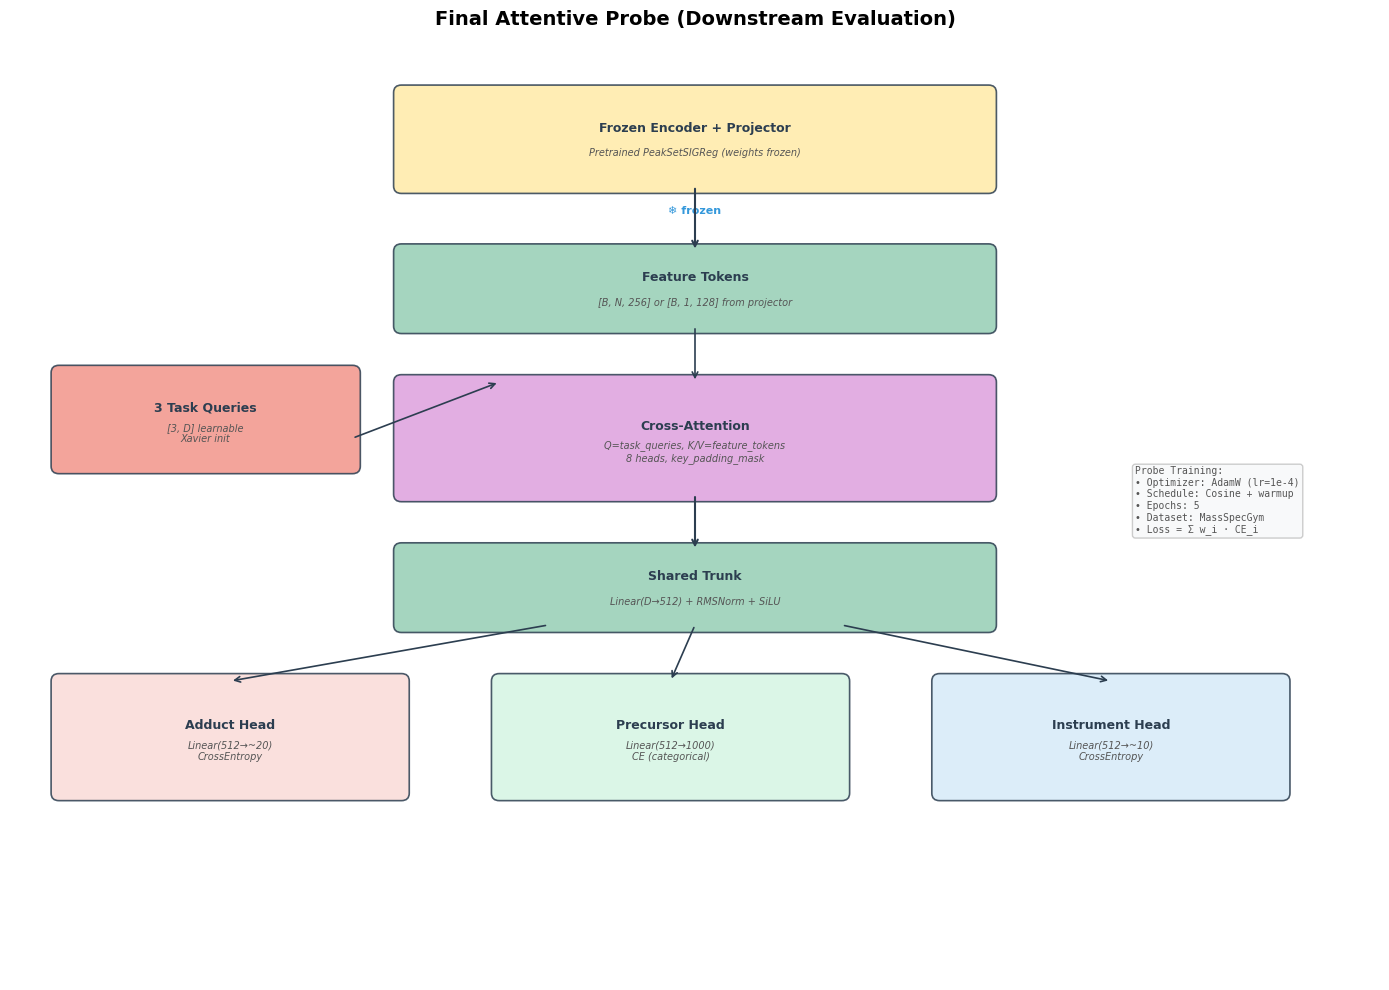

In [10]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Final Attentive Probe (Downstream Evaluation)",
             fontsize=14, fontweight="bold", pad=15)

def pb(ax, x, y, w, h, color, title, sub=""):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                       fc=color, ec="#2C3E50", lw=1.2, alpha=0.85)
    ax.add_patch(b)
    if sub:
        ax.text(x+w/2, y+h/2+0.12, title, ha="center", va="center",
                fontsize=9, fontweight="bold", color="#2C3E50")
        ax.text(x+w/2, y+h/2-0.15, sub, ha="center", va="center",
                fontsize=7, color="#555", style="italic")
    else:
        ax.text(x+w/2, y+h/2, title, ha="center", va="center",
                fontsize=9, fontweight="bold", color="#2C3E50")

# Frozen encoder
pb(ax, 4, 8.5, 6, 1, C["encoder"],
   "Frozen Encoder + Projector",
   "Pretrained PeakSetSIGReg (weights frozen)")
ax.text(7, 8.2, "\u2744 frozen", fontsize=8, color="#3498DB", fontweight="bold", ha="center")

# Feature tokens
pb(ax, 4, 7.0, 6, 0.8, C["embed"],
   "Feature Tokens", "[B, N, 256] or [B, 1, 128] from projector")
ax.annotate("", xy=(7, 7.8), xytext=(7, 8.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))

# Task queries
pb(ax, 0.5, 5.5, 3, 1.0, C["probe"],
   "3 Task Queries", "[3, D] learnable\nXavier init")

# Cross-attention
pb(ax, 4, 5.2, 6, 1.2, C["attn"],
   "Cross-Attention",
   "Q=task_queries, K/V=feature_tokens\n8 heads, key_padding_mask")
ax.annotate("", xy=(5, 6.4), xytext=(3.5, 5.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(7, 6.4), xytext=(7, 7.0),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# Shared trunk
pb(ax, 4, 3.8, 6, 0.8, C["embed"],
   "Shared Trunk", "Linear(D\u2192512) + RMSNorm + SiLU")
ax.annotate("", xy=(7, 4.6), xytext=(7, 5.2),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#2C3E50"))

# Task heads
task_heads = [
    (0.5, 2.0, 3.5, 1.2, "Adduct Head", "Linear(512\u2192~20)\nCrossEntropy"),
    (5.0, 2.0, 3.5, 1.2, "Precursor Head", "Linear(512\u21921000)\nCE (categorical)"),
    (9.5, 2.0, 3.5, 1.2, "Instrument Head", "Linear(512\u2192~10)\nCrossEntropy"),
]
colors_heads = ["#FADBD8", "#D5F5E3", "#D6EAF8"]
for (x, y, w, h, title, sub), col in zip(task_heads, colors_heads):
    pb(ax, x, y, w, h, col, title, sub)

# Arrows to heads
ax.annotate("", xy=(2.25, 3.2), xytext=(5.5, 3.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(6.75, 3.2), xytext=(7, 3.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))
ax.annotate("", xy=(11.25, 3.2), xytext=(8.5, 3.8),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

# Training config
config_text = (
    "Probe Training:\n"
    "\u2022 Optimizer: AdamW (lr=1e-4)\n"
    "\u2022 Schedule: Cosine + warmup\n"
    "\u2022 Epochs: 5\n"
    "\u2022 Dataset: MassSpecGym\n"
    "\u2022 Loss = \u03a3 w_i \u00b7 CE_i"
)
ax.text(11.5, 5.5, config_text, fontsize=7, color="#555",
        verticalalignment="top", family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", fc="#F8F9FA", ec="#CCC"))

plt.tight_layout()
plt.show()

---
## 10. Tensor Shape Flow Summary

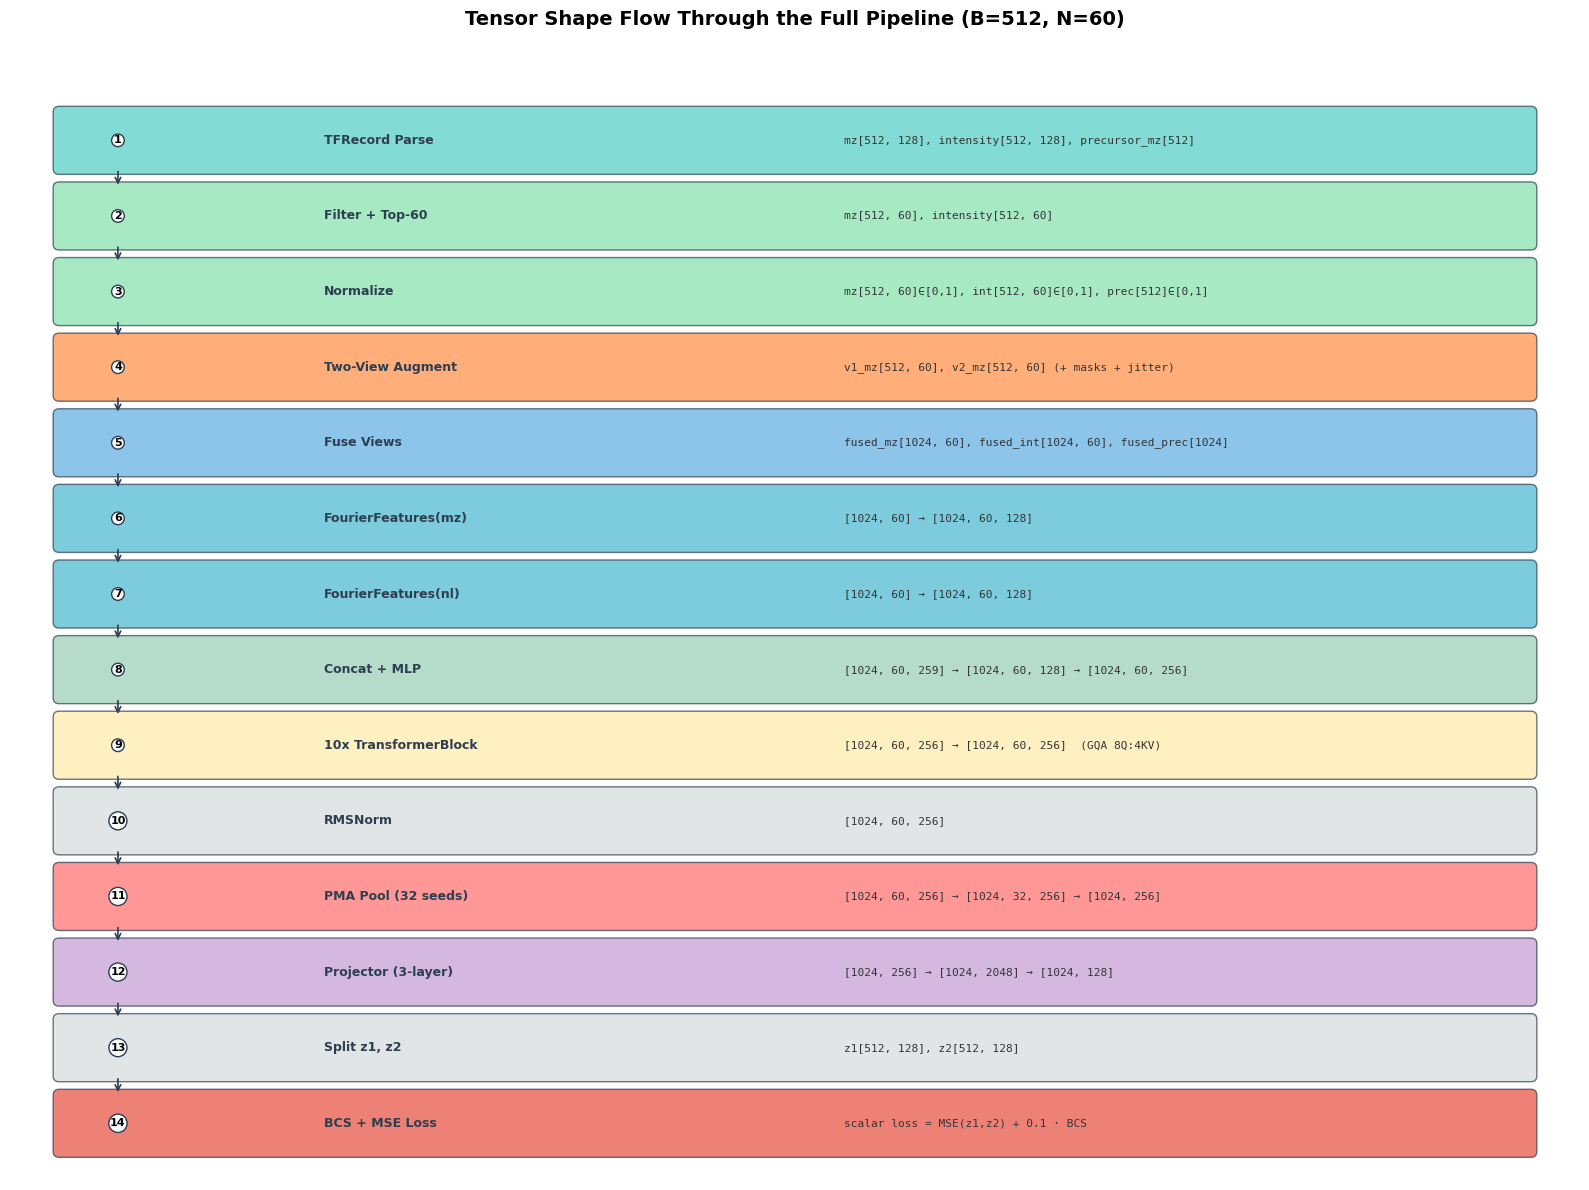

In [11]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis("off")
ax.set_title("Tensor Shape Flow Through the Full Pipeline (B=512, N=60)",
             fontsize=14, fontweight="bold", pad=15)

entries = [
    (11.0, "TFRecord Parse",         "mz[512, 128], intensity[512, 128], precursor_mz[512]",    C["data"]),
    (10.2, "Filter + Top-60",        "mz[512, 60], intensity[512, 60]",                         C["pipeline"]),
    (9.4,  "Normalize",              "mz[512, 60]\u2208[0,1], int[512, 60]\u2208[0,1], prec[512]\u2208[0,1]", C["pipeline"]),
    (8.6,  "Two-View Augment",       "v1_mz[512, 60], v2_mz[512, 60] (+ masks + jitter)",      C["aug_v1"]),
    (7.8,  "Fuse Views",             "fused_mz[1024, 60], fused_int[1024, 60], fused_prec[1024]",C["aug_v2"]),
    (7.0,  "FourierFeatures(mz)",    "[1024, 60] \u2192 [1024, 60, 128]",                       C["fourier"]),
    (6.2,  "FourierFeatures(nl)",    "[1024, 60] \u2192 [1024, 60, 128]",                       C["fourier"]),
    (5.4,  "Concat + MLP",           "[1024, 60, 259] \u2192 [1024, 60, 128] \u2192 [1024, 60, 256]", C["embed"]),
    (4.6,  "10x TransformerBlock",   "[1024, 60, 256] \u2192 [1024, 60, 256]  (GQA 8Q:4KV)",   C["encoder"]),
    (3.8,  "RMSNorm",               "[1024, 60, 256]",                                          C["norm"]),
    (3.0,  "PMA Pool (32 seeds)",    "[1024, 60, 256] \u2192 [1024, 32, 256] \u2192 [1024, 256]", C["pool"]),
    (2.2,  "Projector (3-layer)",    "[1024, 256] \u2192 [1024, 2048] \u2192 [1024, 128]",       C["proj"]),
    (1.4,  "Split z1, z2",           "z1[512, 128], z2[512, 128]",                              C["norm"]),
    (0.6,  "BCS + MSE Loss",         "scalar loss = MSE(z1,z2) + 0.1 \u00b7 BCS",               C["loss"]),
]

for y, stage, shape, color in entries:
    box = FancyBboxPatch((0.5, y - 0.3), 15, 0.6, boxstyle="round,pad=0.06",
                         fc=color, ec="#2C3E50", lw=1, alpha=0.7)
    ax.add_patch(box)
    ax.text(3.2, y, stage, fontsize=9, fontweight="bold", va="center", color="#2C3E50")
    ax.text(8.5, y, shape, fontsize=8, va="center", color="#333", family="monospace")

# Step numbers
for i, (y, *_) in enumerate(entries):
    ax.text(1.1, y, str(i+1), fontsize=8, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="circle,pad=0.12", fc="white", ec="#2C3E50", lw=1))

# Arrows
for i in range(len(entries) - 1):
    y_from = entries[i][0] - 0.3
    y_to = entries[i+1][0] + 0.3
    ax.annotate("", xy=(1.1, y_to), xytext=(1.1, y_from),
                arrowprops=dict(arrowstyle="->", lw=1.2, color="#2C3E50"))

plt.tight_layout()
plt.show()

---
## 11. Model Parameter Count Breakdown

In [12]:
from models.model import PeakSetSIGReg

model = PeakSetSIGReg(
    num_peaks=60,
    model_dim=256,
    encoder_num_layers=10,
    encoder_num_heads=8,
    encoder_num_kv_heads=4,
    attention_mlp_multiple=4.0,
    feature_mlp_hidden_dim=128,
    mz_fourier_num_frequencies=64,
    mz_fourier_min_freq=1.0,
    mz_fourier_max_freq=5000.0,
    pooling_type="pma",
    pma_num_seeds=32,
    pma_num_heads=8,
    sigreg_use_projector=True,
    sigreg_proj_hidden_dim=2048,
    sigreg_proj_output_dim=128,
    bcs_num_slices=512,
    sigreg_lambda=0.1,
)

# Count parameters by component
components = {}
for name, param in model.named_parameters():
    top = name.split(".")[0]
    if top == "encoder":
        sub = name.split(".")[1]
        key = f"encoder.{sub}" if sub in ("embedder", "norm") else "encoder.blocks"
    else:
        key = top
    components[key] = components.get(key, 0) + param.numel()

total = sum(components.values())
print(f"Total parameters: {total:,}\n")
print(f"{'Component':<25} {'Params':>12} {'%':>7}")
print("-" * 46)
for k, v in sorted(components.items(), key=lambda x: -x[1]):
    print(f"{k:<25} {v:>12,} {100*v/total:>6.1f}%")

Total parameters: 12,541,312

Component                       Params       %
----------------------------------------------
encoder.blocks               7,214,080   57.5%
projector                    4,989,056   39.8%
pool_mha                       263,168    2.1%
encoder.embedder                66,304    0.5%
pool_query                       8,192    0.1%
encoder.norm                       256    0.0%
pool_norm                          256    0.0%


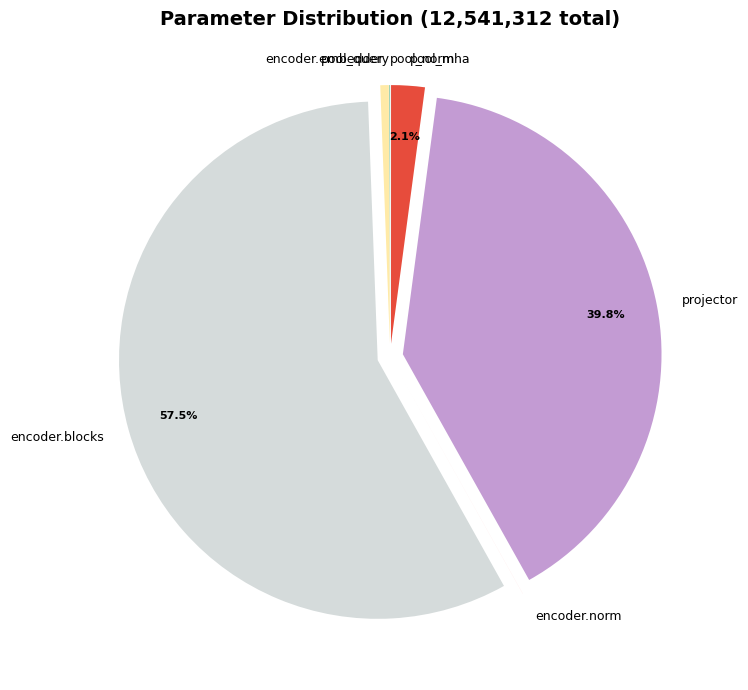

In [13]:
# Pie chart of parameter distribution
fig, ax = plt.subplots(figsize=(10, 7))

labels = list(components.keys())
sizes = list(components.values())
colors_pie = [C["embed"], C["encoder"], C["norm"], C["pool"], C["proj"],
              C["loss"], C["fourier"], C["data"]][:len(labels)]
explode = [0.05] * len(labels)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    colors=colors_pie, explode=explode, startangle=90,
    textprops={"fontsize": 9},
    pctdistance=0.8,
)
for t in autotexts:
    t.set_fontsize(8)
    t.set_fontweight("bold")

ax.set_title(f"Parameter Distribution ({total:,} total)",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

---
## 12. Configuration Summary Table

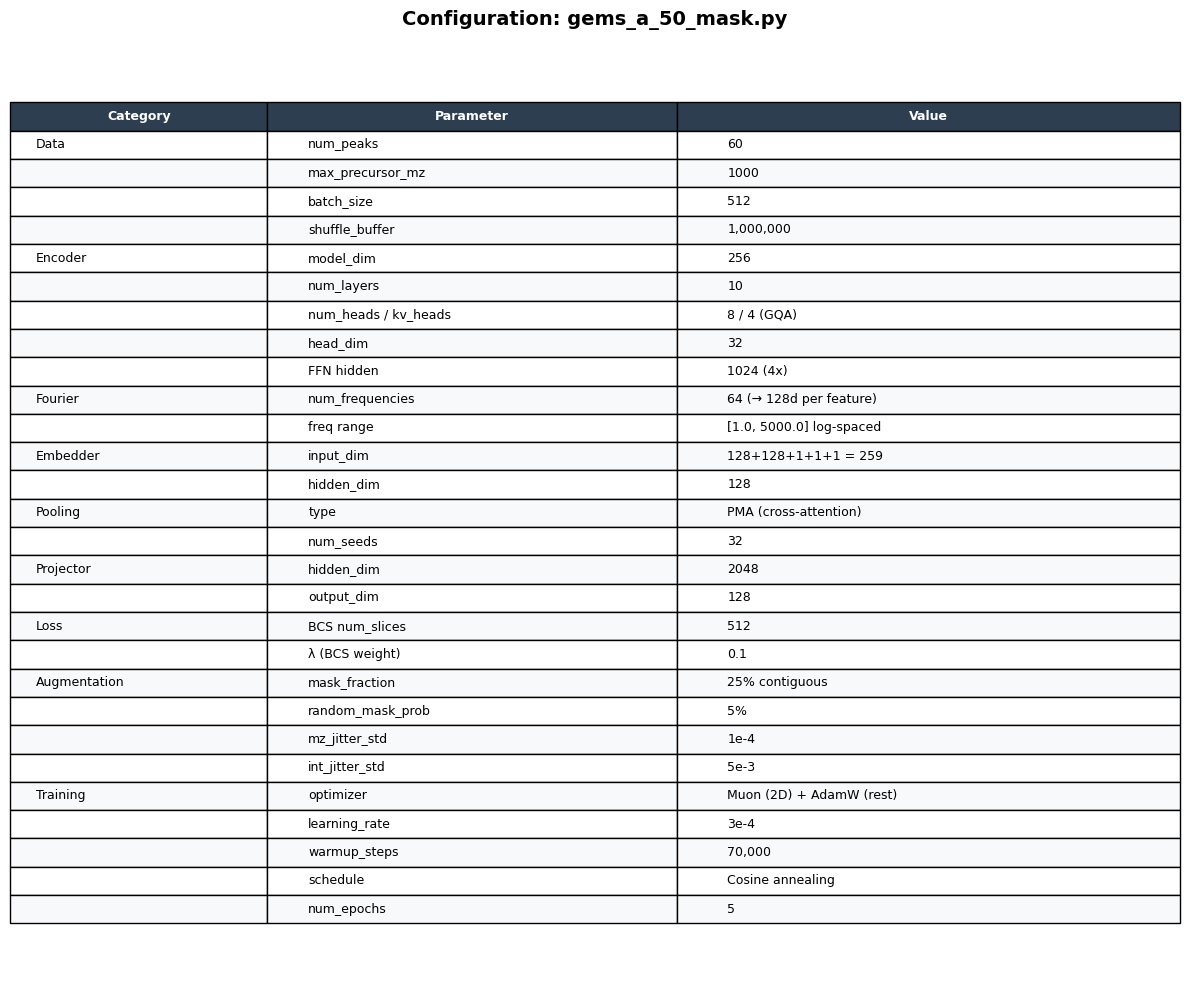

In [14]:
config_data = [
    ["Category", "Parameter", "Value"],
    ["Data", "num_peaks", "60"],
    ["", "max_precursor_mz", "1000"],
    ["", "batch_size", "512"],
    ["", "shuffle_buffer", "1,000,000"],
    ["Encoder", "model_dim", "256"],
    ["", "num_layers", "10"],
    ["", "num_heads / kv_heads", "8 / 4 (GQA)"],
    ["", "head_dim", "32"],
    ["", "FFN hidden", "1024 (4x)"],
    ["Fourier", "num_frequencies", "64 (\u2192 128d per feature)"],
    ["", "freq range", "[1.0, 5000.0] log-spaced"],
    ["Embedder", "input_dim", "128+128+1+1+1 = 259"],
    ["", "hidden_dim", "128"],
    ["Pooling", "type", "PMA (cross-attention)"],
    ["", "num_seeds", "32"],
    ["Projector", "hidden_dim", "2048"],
    ["", "output_dim", "128"],
    ["Loss", "BCS num_slices", "512"],
    ["", "\u03bb (BCS weight)", "0.1"],
    ["Augmentation", "mask_fraction", "25% contiguous"],
    ["", "random_mask_prob", "5%"],
    ["", "mz_jitter_std", "1e-4"],
    ["", "int_jitter_std", "5e-3"],
    ["Training", "optimizer", "Muon (2D) + AdamW (rest)"],
    ["", "learning_rate", "3e-4"],
    ["", "warmup_steps", "70,000"],
    ["", "schedule", "Cosine annealing"],
    ["", "num_epochs", "5"],
]

fig, ax = plt.subplots(figsize=(12, 10))
ax.axis("off")
ax.set_title("Configuration: gems_a_50_mask.py", fontsize=14, fontweight="bold", pad=15)

table = ax.table(
    cellText=config_data[1:],
    colLabels=config_data[0],
    cellLoc="left",
    loc="center",
    colWidths=[0.22, 0.35, 0.43],
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.4)

# Style header
for j in range(3):
    table[0, j].set_facecolor("#2C3E50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Alternate row colors
for i in range(1, len(config_data)):
    color = "#F8F9FA" if i % 2 == 0 else "white"
    for j in range(3):
        table[i, j].set_facecolor(color)

plt.tight_layout()
plt.show()